# Modeling (Classification)

In this section, machine learning models are used to predict customer churn. Since the target variable (`Attrition_Flag`) is categorical, this problem is treated as a classification task.

Logistic Regression is used as the primary classification model. Additionally, a Decision Tree model is implemented as a comparison model.

The models are evaluated using classification metrics including accuracy, precision, recall, and confusion matrix.

---

# Classification

The target variable is:

`Attrition_Flag`

### Values:
- `0` → Existing Customer
- `1` → Churn Customer

### Goal:
Predict whether a customer will churn or not.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("day3_ml_output.csv")

In [2]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Activity_Rate,Credit_Usage,Avg_Transaction_Value
0,768805383,1,45,1,3,39,5,1,3,12691.0,...,0,0,0,1,0,0,0,1.076923,0.061224,27.238095
1,818770008,1,49,0,5,44,6,1,2,8256.0,...,0,1,0,1,0,0,0,0.750000,0.104651,39.121212
2,713982108,1,51,1,3,36,4,1,0,3418.0,...,1,0,0,1,0,0,0,0.555556,0.000000,94.350000
3,769911858,1,40,0,4,34,3,4,1,3313.0,...,0,1,0,1,0,0,0,0.588235,0.759734,58.550000
4,709106358,1,40,1,3,21,5,1,0,4716.0,...,0,0,0,1,0,0,0,1.333333,0.000000,29.142857


In [3]:
X = df.drop('Attrition_Flag', axis=1) ##It removes the Attrition_Flag column from the dataset because that column is the answer.
y = df['Attrition_Flag'] 

# Feature and Target Separation

The dataset was separated into input features (`X`) and the target variable (`y`).

`X` contains all the independent variables that describe customer behavior, such as credit limit, transaction count, and customer activity.

The target variable `y` represents the `Attrition_Flag`, which indicates whether a customer churned or remained with the bank.

Separating the features and target variable allows the machine learning model to learn patterns that help predict customer churn.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000) ## algorithm is allowed up to 1000 iterations to converge.

log_model.fit(X_train, y_train)     ##X_train → customer features

                                    ##y_train → churn label

y_pred = log_model.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(2026,))

### Evaluation Metrics

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.8390918065153011
Precision: 0.8390123456790124
Recall: 1.0


### Logistic Regression Model Evaluation

A Logistic Regression model was trained to predict whether a customer will churn or remain with the bank.

The model was evaluated using three classification metrics:

- **Accuracy** measures the overall correctness of the model predictions. The model achieved an accuracy of approximately **83.9%**, indicating that most predictions were correct.

- **Precision** measures how many of the predicted churn cases were actually correct. The precision score of **0.839** indicates that the majority of predicted churn cases were accurate.

- **Recall** measures how well the model identifies actual churned customers. The recall score of **1.0** indicates that the model successfully identified all churned customers in the test dataset.

Overall, the model demonstrates strong performance in predicting customer churn.

### Confusion Matrix

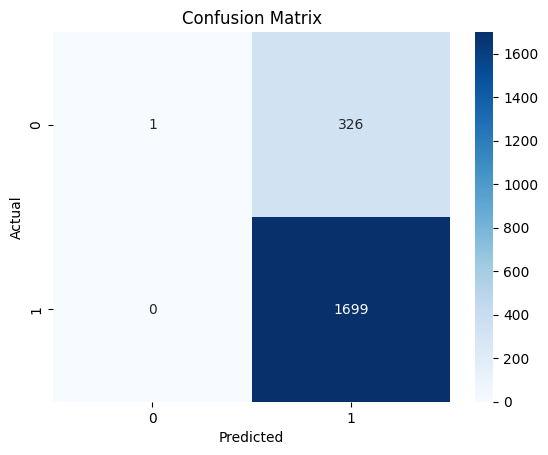

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows the performance of the Logistic Regression model in predicting customer churn.

The model correctly identified 1699 customers who churned (True Positives) and correctly predicted 1 customer who remained with the bank (True Negative).

However, 326 customers were incorrectly predicted as churned even though they actually remained with the bank (False Positives).

Importantly, the model did not miss any churned customers, resulting in zero False Negatives. This explains the recall score of 1.0, meaning the model successfully identified all customers who churned.

Overall, the model demonstrates strong ability to detect churned customers.

### Predicted Churn Customers

The model predicted a total of 2025 customers as churned.

Out of these, 1699 predictions were correct (True Positives), while 326 customers were incorrectly predicted as churned even though they actually remained with the bank (False Positives).

# Day 4 Remark

In this section, a classification model was developed to predict customer churn using the Logistic Regression algorithm. The dataset was first split into training and testing sets to evaluate the model's performance on unseen data.

The Logistic Regression model was trained on the training dataset and used to predict churn for the test dataset. The model's performance was evaluated using accuracy, precision, recall, and a confusion matrix.

The results show that the model achieved an accuracy of approximately 83.9%, indicating good predictive performance. The recall score of 1.0 suggests that the model successfully identified all churned customers, which is important for businesses aiming to prevent customer loss.

In [9]:
df.to_csv("day4_ml_output.csv", index=False)